# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = 'my.garciaazuara@gmail.com'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/my.garciaazuara@gmail.com/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# TODO: Carga el dataset Iris y explora su estructura.
# Pistas:
# - Usa datasets.load_iris()
# - Crea un DataFrame con dataset.data y dataset.feature_names
# - Añade la columna target/especie
# - Muestra shape, clases, primeras filas y estadísticas descriptivas

dataset = datasets.load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target
df['species_name'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

print("Forma del dataset:", df.shape)

print("\nClases:")
print(dataset.target_names)

print("\nPrimeras filas:")
display(df.head())

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nDistribución de especies:")
print(df["species"].value_counts())


Forma del dataset: (150, 6)

Clases:
['setosa' 'versicolor' 'virginica']

Primeras filas:


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
5.1,3.5,1.4,0.2,0,Setosa
4.9,3.0,1.4,0.2,0,Setosa
4.7,3.2,1.3,0.2,0,Setosa
4.6,3.1,1.5,0.2,0,Setosa
5.0,3.6,1.4,0.2,0,Setosa



Estadísticas descriptivas:


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
150.0,150.0,150.0,150.0,150.0
5.843333333333334,3.0573333333333337,3.7580000000000005,1.1993333333333336,1.0
0.828066127977863,0.4358662849366982,1.7652982332594662,0.7622376689603465,0.8192319205190405
4.3,2.0,1.0,0.1,0.0
5.1,2.8,1.6,0.3,0.0
5.8,3.0,4.35,1.3,1.0
6.4,3.3,5.1,1.8,2.0
7.9,4.4,6.9,2.5,2.0



Distribución de especies:
species
0    50
1    50
2    50
Name: count, dtype: int64


### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

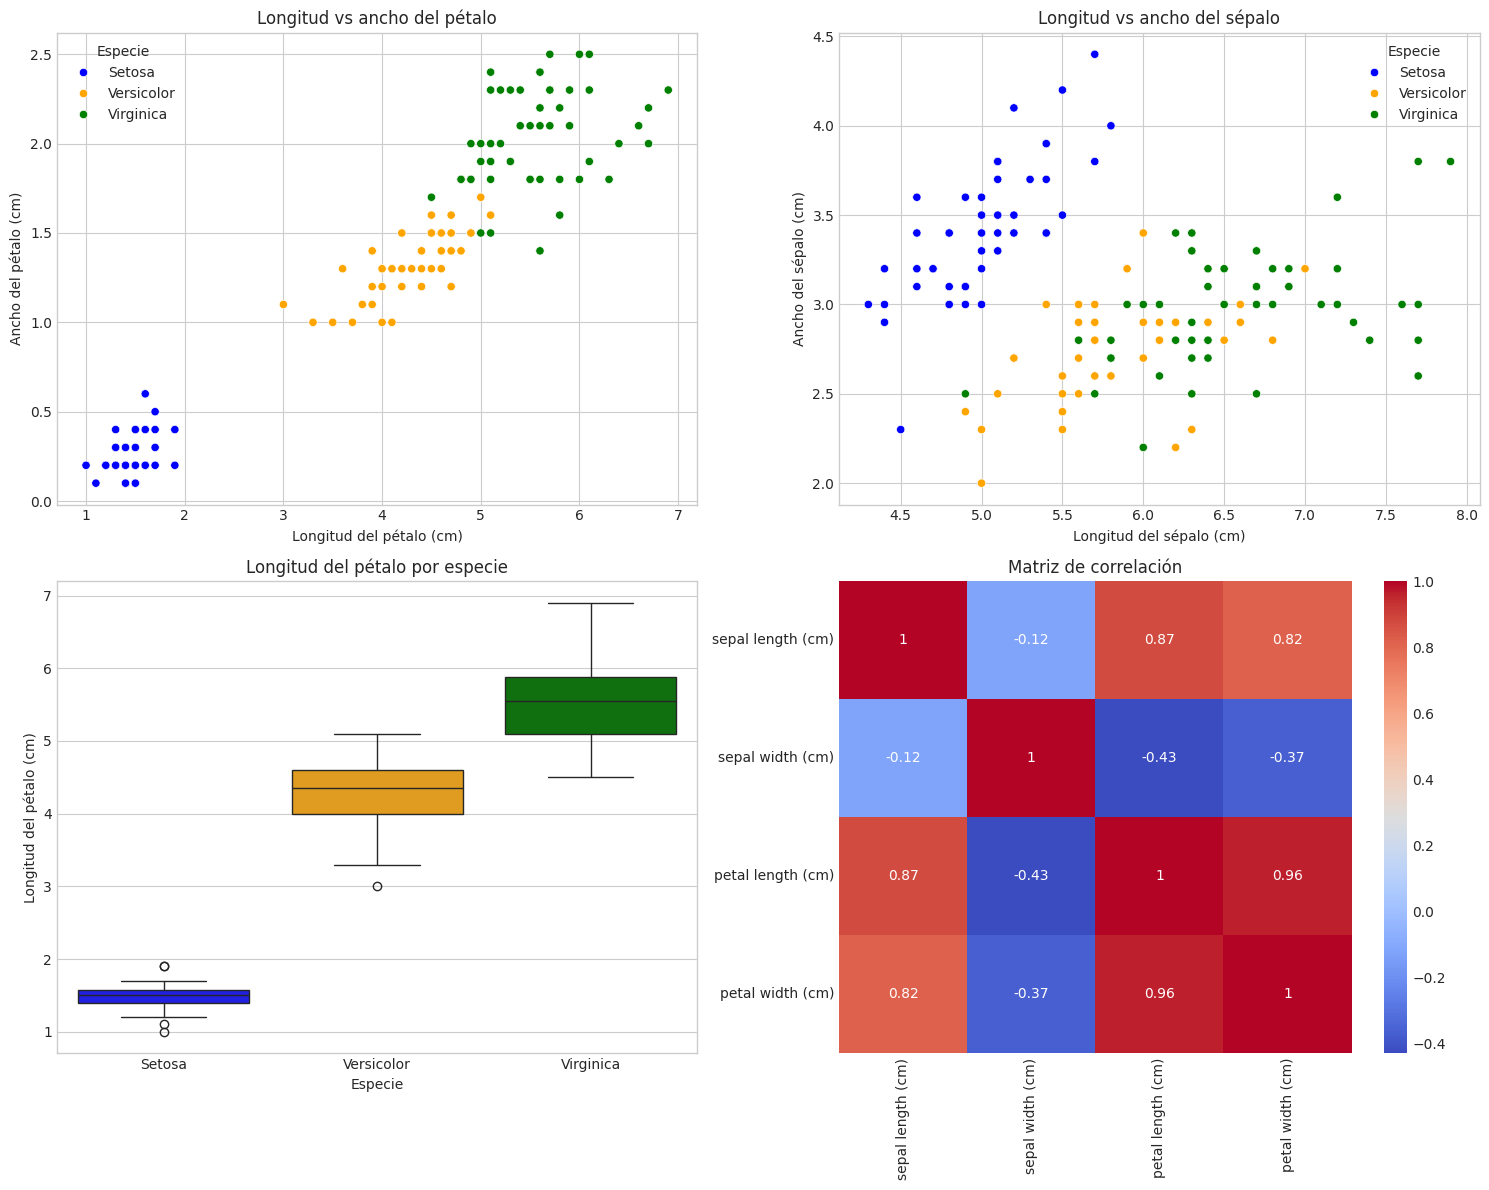

Las medidas del pétalo separan mejor las especies
La especie setosa está más diferenciada de las otras 2
Las especies versicolor y virginica están más solapadas y son más parecidas
Se puede observar una alta correlación entre la longitud y el ancho del pétalo


In [0]:
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por especie
# - Distribución de características por especie
# - Boxplots por especie
# - Matriz de correlación
colores = {
    "Setosa": "blue",
    "Versicolor": "orange",
    "Virginica": "green"
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species_name",
    palette=colores,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Longitud vs ancho del pétalo")
axes[0, 0].set_xlabel("Longitud del pétalo (cm)")
axes[0, 0].set_ylabel("Ancho del pétalo (cm)")
axes[0, 0].legend(title="Especie")

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species_name",
    palette=colores,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Longitud vs ancho del sépalo")
axes[0, 1].set_xlabel("Longitud del sépalo (cm)")
axes[0, 1].set_ylabel("Ancho del sépalo (cm)")
axes[0, 1].legend(title="Especie")

sns.boxplot(
    data=df,
    x="species_name",
    y="petal length (cm)",
    hue="species_name",
    palette=colores,
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Longitud del pétalo por especie")
axes[1, 0].set_xlabel("Especie")
axes[1, 0].set_ylabel("Longitud del pétalo (cm)")

correlation = df[dataset.feature_names].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Matriz de correlación")


plt.tight_layout()
plt.show()

# TODO: Escribe tus observaciones clave sobre separabilidad y correlaciones.
print("Las medidas del pétalo separan mejor las especies")
print("La especie setosa está más diferenciada de las otras 2")
print("Las especies versicolor y virginica están más solapadas y son más parecidas")
print("Se puede observar una alta correlación entre la longitud y el ancho del pétalo")

## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Separa características (X) y etiquetas (y).
X = dataset.data
y = dataset.target

# TODO: Divide el dataset en entrenamiento y prueba.
# Pistas:
# - Usa train_test_split
# - Reserva una parte para test
# - Usa random_state para reproducibilidad
# - Considera stratify=y para mantener la proporción de clases

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TODO: Comprueba tamaños y distribución de clases en cada conjunto.

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print("\nDistribución de clases en el conjunto de entrenamiento:")
print(pd.Series(y_train).value_counts())
print("\nDistribución de clases en el conjunto de prueba:")
print(pd.Series(y_test).value_counts())

Tamaño del conjunto de entrenamiento: 120 (80.0%)
Tamaño del conjunto de prueba: 30 (20.0%)

Distribución de clases en el conjunto de entrenamiento:
0    40
2    40
1    40
Name: count, dtype: int64

Distribución de clases en el conjunto de prueba:
0    10
2    10
1    10
Name: count, dtype: int64


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/09/21 10:21:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o581.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

Accuracy train: 1.0
Accuracy test: 0.9333333333333333
Precision test: 0.9333333333333333
Recall test: 0.9333333333333333
F1-score test: 0.9333333333333333
Overfitting: 0.06666666666666665

Cross Validation:
[0.95833333 0.95833333 0.95833333 0.91666667 1.        ]
Media: 0.9583333333333333


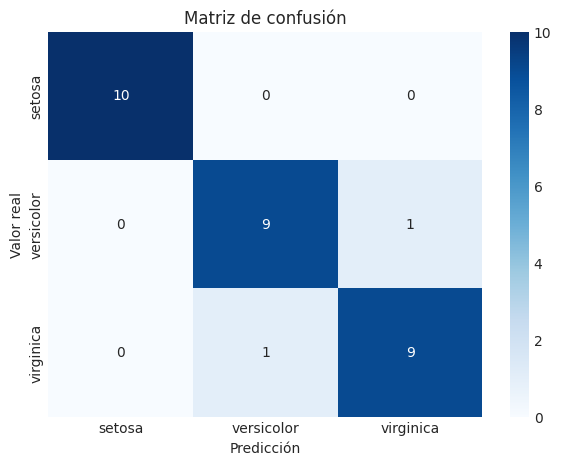

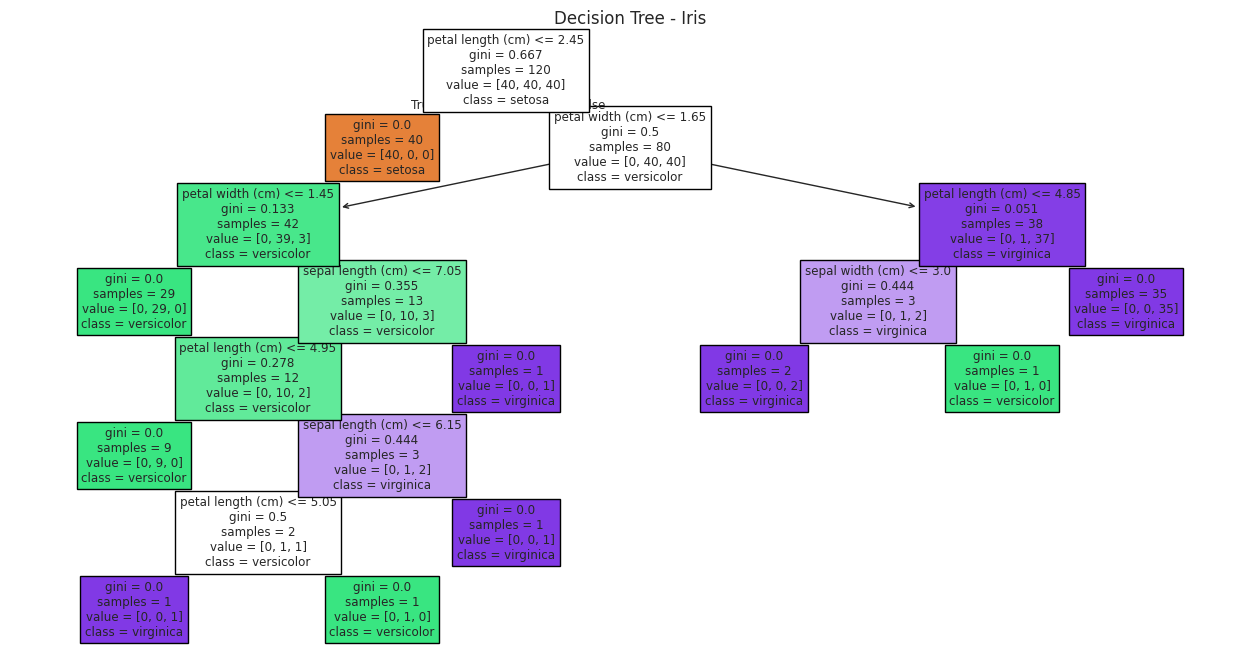

Se ha producido un overfitting moderado con un valor de 0.067. El modelo ha sobreajustado el conjunto de entrenamiento, pero no demasiado. La precisión del modelo en el conjunto de prueba es bastante buena, por lo que se podría considerar como un buen modelo. Además el resto de medidas son bastante buenas, con un precision, recall y f1 del 0.93 en el conjunto de prueba. Además se ha obtenido una media de validación cruzada del 0.96, lo que indica que el modelo es bastante consistente y no varía mucho con diferentes particiones del conjunto de datos


In [0]:
# ========================================
# TODO: ENTRENAMIENTO CON MLFLOW
# ========================================

# TODO: Activa autologging de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run con un nombre descriptivo.
with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
#     TODO: Define hiperparámetros del árbol.
    max_depth = 10
    max_features = 2
    random_state = 42
#
#     TODO: Crea y entrena DecisionTreeClassifier.
    dt = DecisionTreeClassifier(max_depth=max_depth, max_features=max_features, random_state=random_state)
    dt.fit(X_train, y_train)
#
#     TODO: Genera predicciones para train y test.
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
#
#     TODO: Calcula métricas de clasificación.
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
#
#     TODO: Evalúa con cross-validation.
    cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    overfitting = accuracy_train - accuracy_test

    print("Accuracy train:", accuracy_train)
    print("Accuracy test:", accuracy_test)
    print("Precision test:", precision_test)
    print("Recall test:", recall_test)
    print("F1-score test:", f1_test)
    print("Overfitting:", overfitting)
    print("\nCross Validation:")
    print(cv_scores)
    print("Media:", cv_scores.mean())

#     TODO: Registra métricas/parámetros relevantes en MLflow si no quedan registrados automáticamente.
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("max_features", max_features)
    mlflow.log_param("dataset", "Iris")
    mlflow.log_param("n_classes", len(dataset.target_names))
    
    mlflow.log_metric("train_accuracy", accuracy_train)
    mlflow.log_metric("test_accuracy", accuracy_test)
    mlflow.log_metric("test_precision", precision_test)
    mlflow.log_metric("test_recall", recall_test)
    mlflow.log_metric("test_f1", f1_test)
    mlflow.log_metric("cv_mean_accuracy", cv_mean)
    mlflow.log_metric("cv_std_accuracy", cv_std)
    mlflow.log_metric("overfitting_score", overfitting)
#     TODO: Visualiza matriz de confusión y, opcionalmente, el árbol.
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=dataset.target_names,
        yticklabels=dataset.target_names
    )
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.title("Matriz de confusión")
    mlflow.log_figure(
        plt.gcf(),
        "confusion_matrix.png"
    )
    plt.show()

    plt.figure(figsize=(16, 8))
    plot_tree(
        dt,
        feature_names=dataset.feature_names,
        class_names=dataset.target_names,
        filled=True
    )
    plt.title("Decision Tree - Iris")
    mlflow.log_figure(
        plt.gcf(),
        "decision_tree.png"
    )
    plt.show()
mlflow.end_run()
#     TODO: Escribe una breve interpretación de los resultados.
print("Se ha producido un overfitting moderado con un valor de 0.067. El modelo ha sobreajustado el conjunto de entrenamiento, pero no demasiado. La precisión del modelo en el conjunto de prueba es bastante buena, por lo que se podría considerar como un buen modelo. Además el resto de medidas son bastante buenas, con un precision, recall y f1 del 0.93 en el conjunto de prueba. Además se ha obtenido una media de validación cruzada del 0.96, lo que indica que el modelo es bastante consistente y no varía mucho con diferentes particiones del conjunto de datos")

## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración del dataset Iris
2. [ ] Separación train/test
3. [ ] Entrenamiento de un Árbol de Decisión
4. [ ] Evaluación con métricas de clasificación
5. [ ] Registro del experimento en MLflow
6. [ ] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**TODO: Explica con tus palabras:**

- ¿Qué ventajas tiene un árbol de decisión?: 
Es fácil de interpretar, permite visualizar las decisiones realizadas por el modelo, no requiere normalizar previamente las características y admite datos numéricos y categóricos.
- ¿Qué riesgos tiene respecto a overfitting?: 
Es propenso al overfitting si el árbol es demasiado profundo y sensible a pequeños cambios.
- ¿Cómo interpretarías una matriz de confusión multiclase?: 
Muestra cuántas muestras de cada especie han sido clasificadas correctamente y con qué otras especies se confunden. Los elementos de la diagonal representan predicciones correctas y los elementos fuera de ella representan errores. Se pueden dar TP (True Positive) en la diagonal principal y como errores FN (False Negative) y FP (False Positive).
---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**TODO:** ¿Qué combinación da el mejor balance entre accuracy y overfitting?

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

**TODO:** ¿Qué flores se confunden más y por qué?

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


2026/09/21 10:58:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3138.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

Configuración: {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2}
Accuracy test: 0.9333
Overfitting:   0.0333
--------------------------------------------------------------------------------
Configuración: {'max_depth': 5, 'max_features': 3, 'min_samples_split': 5}
Accuracy test: 0.9667
Overfitting:   0.0250
--------------------------------------------------------------------------------
Configuración: {'max_depth': 10, 'max_features': 4, 'min_samples_split': 10}
Accuracy test: 0.9667
Overfitting:   0.0167
--------------------------------------------------------------------------------
Configuración: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2}
Accuracy test: 0.9333
Overfitting:   0.0667
--------------------------------------------------------------------------------
La mejor combinacion es: max_depth=10, max_features=4, min_samples_split=10


2026/09/21 10:58:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3418.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

Mejores parámetros:
{'max_depth': 3, 'max_features': 2, 'min_samples_split': 2}

Mejor Accuracy en Cross-Validation:
0.9666666666666668

Accuracy en Test:


2026/09/21 10:59:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3496.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

...

2026/09/21 10:59:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3515.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

Modelo,Accuracy,F1-Score
KNN,1.0,1.0
SVM,0.9666666666666667,0.9665831244778613
Logistic Regression,0.9666666666666667,0.9665831244778613
Decision Tree,0.9333333333333333,0.9333333333333333
Random Forest,0.9,0.8997493734335839


2026/09/21 10:59:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3776.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

Número total de errores: 2

Muestra: 23
Clase real: virginica
Clase predicha: versicolor
Características: [6.1 2.6 5.6 1.4]

Muestra: 25
Clase real: versicolor
Clase predicha: virginica
Características: [6.7 3.  5.  1.7]


2026/09/21 10:59:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3805.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

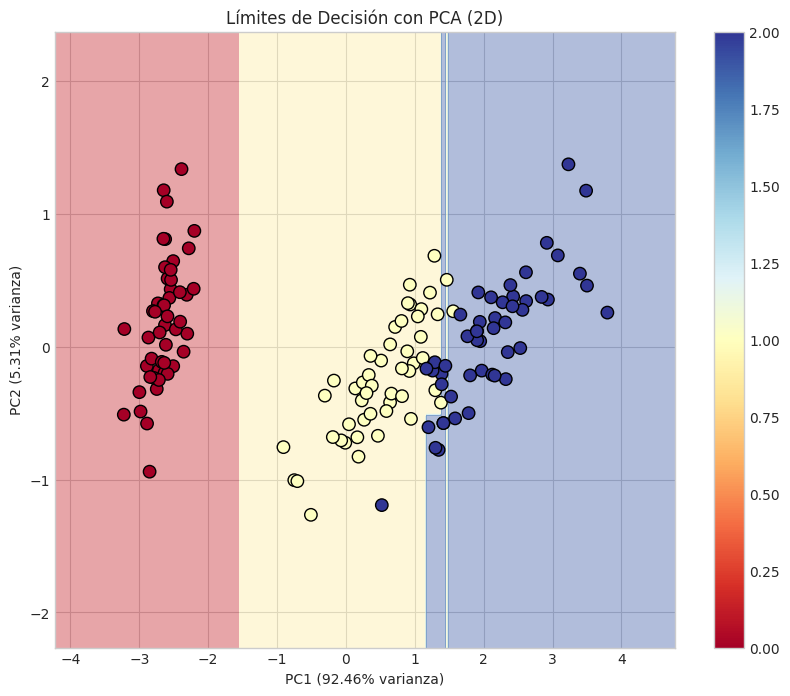

2026/09/21 10:59:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o3883.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

Accuracy con PCA: 0.8947


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del ejercicio.

# ========================================
# TODO: DESAFÍO 1 - Optimización manual
# ========================================
configuraciones = [
    {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2},
    {'max_depth': 5, 'max_features': 3, 'min_samples_split': 5},
    {'max_depth': 10, 'max_features': 4, 'min_samples_split': 10},
    {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2},
]

resultados = []

for config in configuraciones:

    dt = DecisionTreeClassifier(
        **config,
        random_state=42
    )

    dt.fit(X_train, y_train)

    accuracy_train = accuracy_score(
        y_train,
        dt.predict(X_train)
    )

    accuracy_test = accuracy_score(
        y_test,
        dt.predict(X_test)
    )

    overfitting = accuracy_train - accuracy_test

    resultados.append({
        "config": config,
        "accuracy_test": accuracy_test,
        "overfitting": overfitting
    })
for resultado in resultados:

    print("Configuración:", resultado["config"])
    print(f"Accuracy test: {resultado['accuracy_test']:.4f}")
    print(f"Overfitting:   {resultado['overfitting']:.4f}")
    print("-" * 80)
print("La mejor combinacion es: max_depth=10, max_features=4, min_samples_split=10")

# ========================================
# TODO: DESAFÍO 2 - Grid Search
# ========================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 10, None],
    "max_features": [2, 3, 4, "sqrt"],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor Accuracy en Cross-Validation:")
print(grid_search.best_score_)

y_pred_grid = grid_search.predict(X_test)

print("\nAccuracy en Test:")
print(
    accuracy_score(
        y_test,
        y_pred_grid
    )
)
# ========================================
# TODO: DESAFÍO 3 - Comparación de modelos
# ========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

modelos = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "SVM": SVC(),

    "KNN": KNeighborsClassifier(),

    "Logistic Regression": LogisticRegression(
        max_iter=200
    )
}


resultados = []

for nombre, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "F1-Score": f1
    })


df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    "Accuracy",
    ascending=False
)

display(df_resultados)

# ========================================
# TODO: DESAFÍO 4 - Análisis de errores
# ========================================
y_pred_test = dt.predict(X_test)

incorrect_indices = np.where(
    y_pred_test != y_test
)[0]

print(
    "Número total de errores:",
    len(incorrect_indices)
)

for idx in incorrect_indices:

    clase_real = dataset.target_names[
        y_test[idx]
    ]

    clase_predicha = dataset.target_names[
        y_pred_test[idx]
    ]

    print("\nMuestra:", idx)

    print(
        "Clase real:",
        clase_real
    )

    print(
        "Clase predicha:",
        clase_predicha
    )

    print(
        "Características:",
        X_test[idx]
    )
# ========================================
# TODO: DESAFÍO 5 - PCA y visualización 2D
# ========================================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

dt_pca = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_pca.fit(
    X_train_pca,
    y_train_pca
)

from matplotlib.colors import ListedColormap

h = 0.02

x_min = X_pca[:, 0].min() - 1
x_max = X_pca[:, 0].max() + 1

y_min = X_pca[:, 1].min() - 1
y_max = X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = dt_pca.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.4,
    cmap=plt.cm.RdYlBu
)

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    edgecolors='black',
    s=80,
    cmap=plt.cm.RdYlBu
)

plt.xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)'
)

plt.ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)'
)

plt.title(
    'Límites de Decisión con PCA (2D)'
)

plt.colorbar(scatter)

plt.show()

print(
    f"Accuracy con PCA: "
    f"{accuracy_score(y_test_pca, dt_pca.predict(X_test_pca)):.4f}"
)